<a href="https://colab.research.google.com/github/bhuvan-420/FlipItNews-NLP-Classification/blob/main/FlipItNews_NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Importing the libraries & Reading the data file**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving flipitnews-data.csv to flipitnews-data.csv


In [4]:
# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the dataset

df = pd.read_csv('/content/flipitnews-data.csv')

# Display first 5 rows

df.head()

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


**2. Exploring the dataset**

**Shape of the dataset**
**News articles per category**

In [5]:
# Shape of the dataset

df.shape

(2225, 2)

In [6]:
# Number of news articles in each category

df['Category'].value_counts()

,count
Category,
Sports,511
Business,510
Politics,417
Technology,401
Entertainment,386


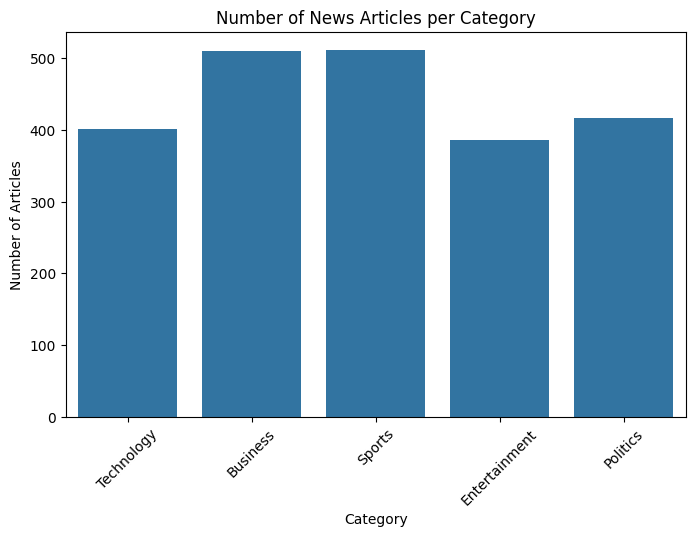

**Observation:**
The dataset contains 2225 news articles across 5 different categories.
Sports and Business have the highest number of articles, while
Entertainment has the lowest number of articles.

# **3. Processing the Textual Data i.e. the news articles **

**Removing the non-letters**

**Tokenizing the text**

**Removing stopwords**

**Lemmatization**

**Processing the Textual **

In [8]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**Text preprocessing function**

In [9]:
# Initialize stopwords and lemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):

    # 1. Remove non-letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))

    # Convert to lowercase
    text = text.lower()

    # 2. Tokenize the text
    words = word_tokenize(text)

    # 3. Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # 4. Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return ' '.join(words)

**Apply the function to Article column**

In [10]:
df['Processed_Article'] = df['Article'].apply(preprocess_text)

Check the processed data

In [13]:
df[['Article', 'Processed_Article']].head(8)

,Article,Processed_Article
0,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
1,worldcom boss left books alone former worldc...,worldcom bos left book alone former worldcom b...
2,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rushed...
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...
5,howard hits back at mongrel jibe michael howar...,howard hit back mongrel jibe michael howard sa...
6,blair prepares to name poll date tony blair is...,blair prepares name poll date tony blair likel...
7,henman hopes ended in dubai third seed tim hen...,henman hope ended dubai third seed tim henman ...


**Single article — Before & After**

In [12]:
  print("Before Processing:\n")
  print(df['Article'].iloc[0])

  print("\n" + "="*80 + "\n")

  print("After Processing:\n")
  print(df['Processed_Article'].iloc[0])

Before Processing:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also bei

**Observation:**

The textual data was preprocessed using Natural Language Processing
techniques. Non-letter characters were removed to clean the news
articles. The cleaned text was then tokenized into individual words.

Common English stopwords that do not contribute much meaning to the
classification task were removed. Finally, lemmatization was performed
to convert words into their meaningful root forms.

These preprocessing steps help reduce noise and dimensionality in the
text data and make the news articles more suitable for further
vectorization and classification.

# 4. Encoding and Transforming the data

Encoding the target variable

Bag of Words

TF-IDF

Train-Test Split

**4.1 Encoding the Target Variable**

In [14]:
from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Encode the target variable
y = label_encoder.fit_transform(df['Category'])

# Display category mapping
category_mapping = dict(zip(label_encoder.classes_,
                            label_encoder.transform(label_encoder.classes_)))

category_mapping

{'Business': np.int64(0),
 'Entertainment': np.int64(1),
 'Politics': np.int64(2),
 'Sports': np.int64(3),
 'Technology': np.int64(4)}

**Observation:**
The categorical target variable was converted into numerical labels
using Label Encoding. Each news category is represented by a unique
integer value, making it suitable for machine learning algorithms.

**4.2 Bag of Words**

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer
bow_vectorizer = CountVectorizer()

# Transform the processed articles
X_bow = bow_vectorizer.fit_transform(df['Processed_Article'])

print("Bag of Words Shape:", X_bow.shape)

Bag of Words Shape: (2225, 24728)


**4.3 TF-IDF**

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Transform the processed articles
X_tfidf = tfidf_vectorizer.fit_transform(df['Processed_Article'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (2225, 24728)


**Observation:**
Bag of Wo ds represents each article based on the frequency of words,
while TF-IDF assigns higher importance to words that are more relevant
to an article and less common across all articles.

**4.4 Train-Test Split**

In [17]:
from sklearn.model_selection import train_test_split

# Train-Test Split using TF-IDF features
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1780, 24728)
Testing data shape: (445, 24728)


**Observation:**
The dataset was divided into 80% training data and 20% testing data.
Stratified splitting was used to maintain a similar category
distribution in both training and testing datasets.

**Insight:**

The target variable was successfully encoded into numerical labels, while the text data was transformed into numerical features using Bag of Words and TF-IDF. The dataset was then split into 80% training and 20% testing data, with stratification maintaining a balanced category distribution.

# 5. Model Training & Evaluation

Simple Approach
Naive Bayes

**5.1 Naive Bayes – Model Training**

In [18]:
from sklearn.naive_bayes import MultinomialNB

# Initialize Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict on test data
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


Model Evaluation

In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=label_encoder.classes_
))

Naive Bayes Accuracy: 0.9842696629213483

Classification Report:

               precision    recall  f1-score   support

     Business       0.98      0.98      0.98       102
Entertainment       1.00      0.96      0.98        77
     Politics       0.94      1.00      0.97        84
       Sports       1.00      1.00      1.00       102
   Technology       1.00      0.97      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



**Confusion Matrix**

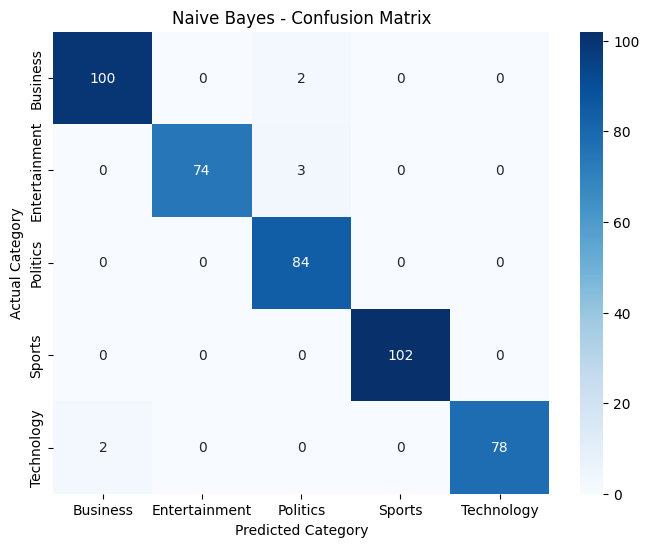

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

**Insight:**

Naive Bayes was trained using TF-IDF features to classify news articles into five categories. The model provides a simple and efficient baseline for multi-class text classification. Its performance was evaluated using accuracy, classification report, and confusion matrix.

# 5.2 Functionalized Code

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_evaluate_model(model, model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", accuracy)
    print("\nClassification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    return accuracy, y_pred

**1. Decision Tree**

In [22]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_accuracy, y_pred_dt = train_evaluate_model(
    dt_model,
    "Decision Tree"
)

Decision Tree
Accuracy: 0.8719101123595505

Classification Report:

               precision    recall  f1-score   support

     Business       0.89      0.83      0.86       102
Entertainment       0.82      0.95      0.88        77
     Politics       0.84      0.81      0.82        84
       Sports       0.94      0.92      0.93       102
   Technology       0.86      0.85      0.86        80

     accuracy                           0.87       445
    macro avg       0.87      0.87      0.87       445
 weighted avg       0.87      0.87      0.87       445



**2. Nearest Neighbors (KNN)**

In [23]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_accuracy, y_pred_knn = train_evaluate_model(
    knn_model,
    "K-Nearest Neighbors"
)

K-Nearest Neighbors
Accuracy: 0.9235955056179775

Classification Report:

               precision    recall  f1-score   support

     Business       0.93      0.88      0.90       102
Entertainment       0.96      0.91      0.93        77
     Politics       0.84      0.93      0.88        84
       Sports       0.96      0.97      0.97       102
   Technology       0.94      0.93      0.93        80

     accuracy                           0.92       445
    macro avg       0.92      0.92      0.92       445
 weighted avg       0.93      0.92      0.92       445



# 3. Random Forest

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_accuracy, y_pred_rf = train_evaluate_model(
    rf_model,
    "Random Forest"
)

Random Forest
Accuracy: 0.9707865168539326

Classification Report:

               precision    recall  f1-score   support

     Business       0.97      0.98      0.98       102
Entertainment       0.97      0.99      0.98        77
     Politics       0.96      0.92      0.94        84
       Sports       0.98      1.00      0.99       102
   Technology       0.96      0.96      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



# Model Comparison

In [25]:
model_results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Decision Tree',
        'K-Nearest Neighbors',
        'Random Forest'
    ],
    'Accuracy': [
        nb_accuracy,
        dt_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

model_results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Naive Bayes,0.984270
3,Random Forest,0.970787
2,K-Nearest Neighbors,0.923596
1,Decision Tree,0.871910


**Insight:**

The functionalized approach allows multiple classification models to be trained and evaluated using the same procedure. Decision Tree, K-Nearest Neighbors, and Random Forest were implemented and their performances can be compared with the Naive Bayes baseline. The model with the highest test accuracy can be considered the best-performing model for this dataset.